In [1]:
# CELL 1
# Load the RSHQ quarterly frequency rates file and inspect the Minerals Surface sheet.
# This sheet contains monthly serious accident and high potential incident frequency
# rates for all Queensland surface mineral mines — same category as Ravenswood Gold.
# Header is at index 2, index 3 is a spacer, actual data starts at index 4.

import pandas as pd
import os

file_path = os.path.join('..', 'data', 'raw',
                         'quarterly-frequency-rates1july2012to31december2025.xlsx')

df_raw = pd.read_excel(file_path, sheet_name='Minerals Surface', header=None)

print(f"Sheet dimensions: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print()
print("Row 2 (headers):", df_raw.iloc[2, :12].tolist())
print()
print("Row 4 (first data row):", df_raw.iloc[4, :12].tolist())
print("Row 5 (second data row):", df_raw.iloc[5, :12].tolist())

Sheet dimensions: 166 rows x 12 columns

Row 2 (headers): ['Month', 'SAs', 'HPIs', 'Million Hours Worked', 'SAFR', 'Monthly Average', '3 Month Rolling Average', '12 Month Rolling Average', 'HPIFR', 'Monthly Average', '3 Month Rolling Average', '12 Month Rolling Average']

Row 4 (first data row): [datetime.datetime(2012, 7, 1, 0, 0), 0, 15, 1.240342, 0, 0, nan, nan, 12.093438745120297, 12.093438745120297, nan, nan]
Row 5 (second data row): [datetime.datetime(2012, 8, 1, 0, 0), 1, 21, 1.328289, 0.7528482130018391, 0.3893124391942634, nan, nan, 15.809812473038622, 14.015247810993483, nan, nan]


In [2]:
# CELL 2
# Extract the Minerals Surface safety data with proper column names.
# Month is already parsed as datetime by Excel — no conversion needed.
# We rename the duplicate Monthly Average, 3 Month Rolling Average and
# 12 Month Rolling Average columns to distinguish between SAFR and HPIFR series.
# Data runs from July 2012 to December 2025 — 162 months of safety history.

# Read with header at row 2
df_safety = pd.read_excel(file_path, sheet_name='Minerals Surface', header=2)

# Drop spacer row (index 0 in df_safety = row 3 in Excel)
df_safety = df_safety.drop(index=0).reset_index(drop=True)

# Rename columns to avoid duplicates
df_safety.columns = [
    'month', 'serious_accidents', 'hpi_count',
    'million_hours_worked', 'safr', 'safr_monthly_avg',
    'safr_3mth_rolling', 'safr_12mth_rolling',
    'hpifr', 'hpifr_monthly_avg',
    'hpifr_3mth_rolling', 'hpifr_12mth_rolling'
]

# Convert month to datetime
df_safety['month'] = pd.to_datetime(df_safety['month'])

# Convert all numeric columns
numeric_cols = df_safety.columns.drop('month')
df_safety[numeric_cols] = df_safety[numeric_cols].apply(
    pd.to_numeric, errors='coerce')

# Drop any rows where month is NaT (catches chart data at bottom of sheet)
df_safety = df_safety[df_safety['month'].notna()].reset_index(drop=True)

# Add financial year column
def assign_financial_year(date):
    if date.month >= 7:
        return f"{date.year}-{str(date.year + 1)[2:]}"
    else:
        return f"{date.year - 1}-{str(date.year)[2:]}"

df_safety['financial_year'] = df_safety['month'].apply(assign_financial_year)

print(f"Total months extracted: {len(df_safety)}")
print(f"Date range: {df_safety['month'].min().strftime('%b %Y')} to "
      f"{df_safety['month'].max().strftime('%b %Y')}")
print()
print(df_safety.head(5).to_string(index=False))

Total months extracted: 162
Date range: Jul 2012 to Dec 2025

     month  serious_accidents  hpi_count  million_hours_worked     safr  safr_monthly_avg  safr_3mth_rolling  safr_12mth_rolling     hpifr  hpifr_monthly_avg  hpifr_3mth_rolling  hpifr_12mth_rolling financial_year
2012-07-01                0.0       15.0              1.240342 0.000000          0.000000                NaN                 NaN 12.093439          12.093439                 NaN                  NaN        2012-13
2012-08-01                1.0       21.0              1.328289 0.752848          0.389312                NaN                 NaN 15.809812          14.015248                 NaN                  NaN        2012-13
2012-09-01                1.0        9.0              1.299686 0.769417          0.517021           0.517021                 NaN  6.924750          11.632966           11.632966                  NaN        2012-13
2012-10-01                0.0       11.0              1.361587 0.000000          0

In [3]:
# CELL 3
# Aggregate monthly safety data to financial year level for joining with
# the production and labour pillars in the database.
# We sum raw counts (SAs, HPIs, hours worked) and average the frequency rates.
# The 12-month rolling average at June each year is used as the annual benchmark
# rate — this is how RSHQ reports annual performance officially.

# Annual aggregation
df_safety_annual = df_safety.groupby('financial_year').agg(
    total_serious_accidents=('serious_accidents', 'sum'),
    total_hpi_count=('hpi_count', 'sum'),
    total_million_hours=('million_hours_worked', 'sum'),
    avg_safr=('safr', 'mean'),
    avg_hpifr=('hpifr', 'mean'),
    peak_safr=('safr', 'max'),
    peak_hpifr=('hpifr', 'max'),
    months_reported=('month', 'count')
).reset_index()

# Round for readability
df_safety_annual['total_million_hours'] = df_safety_annual['total_million_hours'].round(2)
df_safety_annual['avg_safr'] = df_safety_annual['avg_safr'].round(3)
df_safety_annual['avg_hpifr'] = df_safety_annual['avg_hpifr'].round(3)
df_safety_annual['peak_safr'] = df_safety_annual['peak_safr'].round(3)
df_safety_annual['peak_hpifr'] = df_safety_annual['peak_hpifr'].round(3)
df_safety_annual['total_serious_accidents'] = df_safety_annual[
    'total_serious_accidents'].astype(int)
df_safety_annual['total_hpi_count'] = df_safety_annual['total_hpi_count'].astype(int)

# Extract June end-of-year 12-month rolling average as official annual benchmark
june_rows = df_safety[df_safety['month'].dt.month == 6][
    ['financial_year', 'safr_12mth_rolling', 'hpifr_12mth_rolling']].copy()
june_rows.columns = ['financial_year', 'safr_12mth_annual', 'hpifr_12mth_annual']

df_safety_annual = df_safety_annual.merge(june_rows, on='financial_year', how='left')

print(df_safety_annual.to_string(index=False))

financial_year  total_serious_accidents  total_hpi_count  total_million_hours  avg_safr  avg_hpifr  peak_safr  peak_hpifr  months_reported  safr_12mth_annual  hpifr_12mth_annual
       2012-13                        5              157                15.51     0.326     10.181      0.828      15.810               12           0.322311           10.120577
       2013-14                        4              118                14.41     0.281      8.187      0.969      12.259               12           0.277588            8.188848
       2014-15                        2              137                11.84     0.156     11.552      1.080      16.204               12           0.168923           11.571241
       2015-16                        2              146                 9.89     0.179     14.887      1.130      22.529               12           0.202191           14.759949
       2016-17                        2              159                10.23     0.203     15.701      1.220 

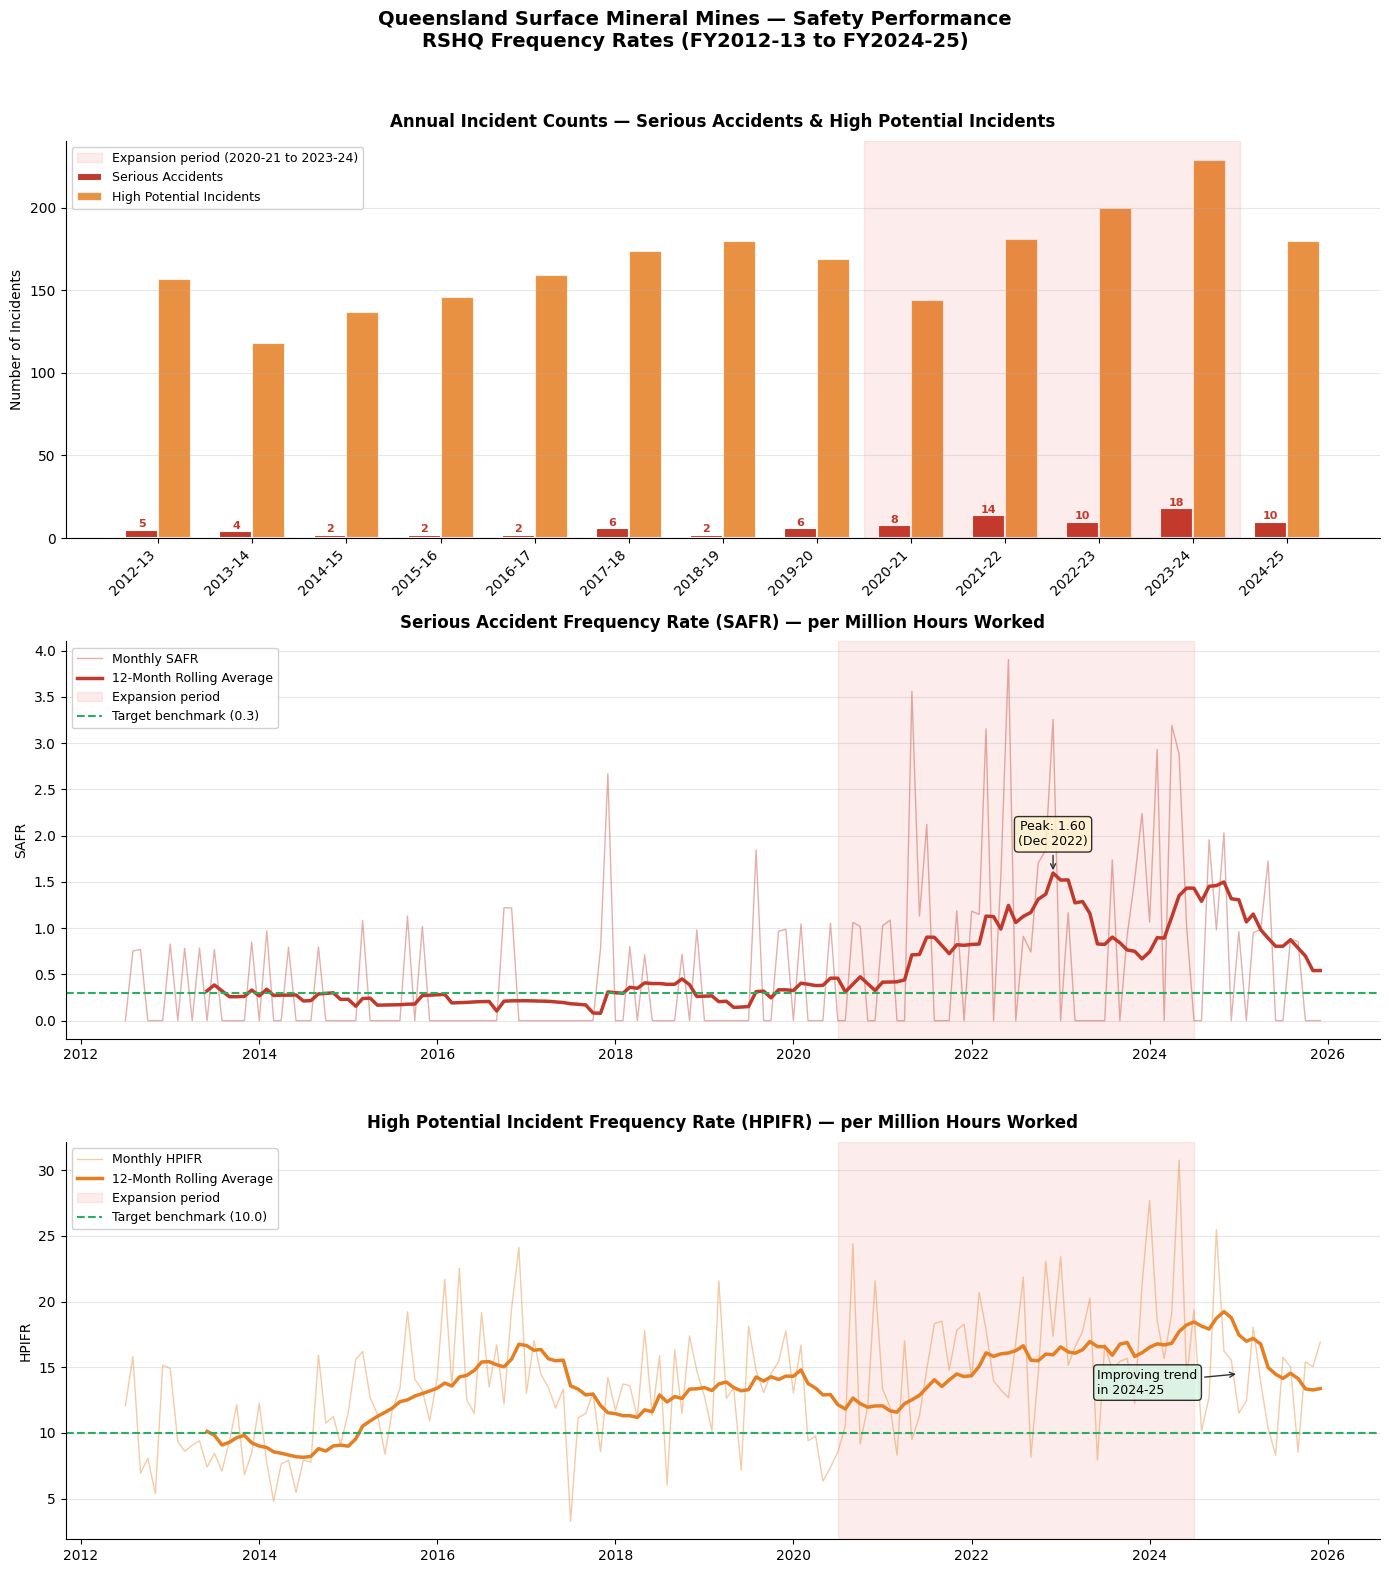

Chart saved to output/04_safety_trends.png


In [4]:
# CELL 4
# Visualise Queensland surface mineral mine safety performance across three charts:
#   1. Annual serious accidents and HPI counts (raw incident volume)
#   2. SAFR trend with 12-month rolling average (frequency rate normalised by hours)
#   3. HPIFR trend with 12-month rolling average (leading indicator)
# Key insight: safety performance deteriorated during the 2020-2024 expansion period —
# linking directly to the production and labour pillars built in earlier notebooks.
# 2025-26 is excluded from annual charts as it only has 6 months of data.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Exclude incomplete 2025-26 from annual charts
df_annual_plot = df_safety_annual[df_safety_annual['financial_year'] != '2025-26'].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle('Queensland Surface Mineral Mines — Safety Performance\n'
             'RSHQ Frequency Rates (FY2012-13 to FY2024-25)',
             fontsize=14, fontweight='bold', y=0.98)

years = df_annual_plot['financial_year']
x = range(len(years))

# Expansion period indices for shading
exp_start = list(years).index('2020-21')
exp_end = list(years).index('2023-24')

# --- Chart 1: Raw incident counts ---
ax1 = axes[0]
width = 0.35
bars_sa = ax1.bar([i - width/2 for i in x],
                  df_annual_plot['total_serious_accidents'],
                  width=width, label='Serious Accidents',
                  color='#C0392B', edgecolor='white', linewidth=1.5)
bars_hpi = ax1.bar([i + width/2 for i in x],
                   df_annual_plot['total_hpi_count'],
                   width=width, label='High Potential Incidents',
                   color='#E67E22', edgecolor='white', linewidth=1.5,
                   alpha=0.85)

# Shade expansion period
ax1.axvspan(exp_start - 0.5, exp_end + 0.5, alpha=0.1, color='#E74C3C',
            label='Expansion period (2020-21 to 2023-24)')
ax1.set_title('Annual Incident Counts — Serious Accidents & High Potential Incidents',
              fontweight='bold', pad=10)
ax1.set_ylabel('Number of Incidents')
ax1.set_xticks(x)
ax1.set_xticklabels(years, rotation=45, ha='right')
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)

# Label serious accident bars only
for bar in bars_sa:
    if bar.get_height() > 0:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{int(bar.get_height())}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold',
                 color='#C0392B')
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Chart 2: SAFR trend ---
ax2 = axes[1]
ax2.plot(df_safety['month'], df_safety['safr'],
         color='#C0392B', linewidth=1, alpha=0.4, label='Monthly SAFR')
ax2.plot(df_safety['month'], df_safety['safr_12mth_rolling'],
         color='#C0392B', linewidth=2.5, label='12-Month Rolling Average')

# Shade expansion period using dates
ax2.axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2024-06-30'),
            alpha=0.1, color='#E74C3C', label='Expansion period')

# Industry benchmark line
ax2.axhline(y=0.3, color='#27AE60', linestyle='--', linewidth=1.5,
            label='Target benchmark (0.3)')

ax2.set_title('Serious Accident Frequency Rate (SAFR) — per Million Hours Worked',
              fontweight='bold', pad=10)
ax2.set_ylabel('SAFR')
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Annotate peak
peak_safr_idx = df_safety['safr_12mth_rolling'].idxmax()
peak_date = df_safety.loc[peak_safr_idx, 'month']
peak_val = df_safety.loc[peak_safr_idx, 'safr_12mth_rolling']
ax2.annotate(f'Peak: {peak_val:.2f}\n({peak_date.strftime("%b %Y")})',
             xy=(peak_date, peak_val),
             xytext=(peak_date, peak_val + 0.3),
             arrowprops=dict(arrowstyle='->', color='#333333'),
             fontsize=9, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', alpha=0.8))

# --- Chart 3: HPIFR trend ---
ax3 = axes[2]
ax3.plot(df_safety['month'], df_safety['hpifr'],
         color='#E67E22', linewidth=1, alpha=0.4, label='Monthly HPIFR')
ax3.plot(df_safety['month'], df_safety['hpifr_12mth_rolling'],
         color='#E67E22', linewidth=2.5, label='12-Month Rolling Average')

ax3.axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2024-06-30'),
            alpha=0.1, color='#E74C3C', label='Expansion period')

ax3.axhline(y=10, color='#27AE60', linestyle='--', linewidth=1.5,
            label='Target benchmark (10.0)')

ax3.set_title('High Potential Incident Frequency Rate (HPIFR) — per Million Hours Worked',
              fontweight='bold', pad=10)
ax3.set_ylabel('HPIFR')
ax3.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax3.grid(axis='y', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Annotate improving trend in 2024-25
ax3.annotate('Improving trend\nin 2024-25',
             xy=(pd.Timestamp('2025-01-01'), 14.5),
             xytext=(pd.Timestamp('2023-06-01'), 13.0),
             arrowprops=dict(arrowstyle='->', color='#333333'),
             fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#D5F5E3', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.96])

output_dir = os.path.join('..', 'output')
plt.savefig(os.path.join(output_dir, '04_safety_trends.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to output/04_safety_trends.png")

In [5]:
# CELL 5
# Link the annual safety data to the production master to show the relationship
# between increased throughput (expansion) and safety performance deterioration.
# We calculate two additional derived metrics:
#   1. Incidents per million tonnes — normalises safety risk by production volume
#   2. HPI to SA ratio — measures how effectively HPIs are being converted to
#      preventive action before serious accidents occur. A rising ratio means
#      more near-misses are being caught before becoming serious accidents (good).
#      A falling ratio means near-misses are being missed (bad).
# This three-pillar linkage is the core analytical narrative of the portfolio.

# Load production master
production_path = os.path.join('..', 'data', 'processed', 'production',
                                'gold_production_qld.csv')
production_master = pd.read_csv(production_path)

# Merge safety annual with production on financial year
safety_production = df_safety_annual.merge(
    production_master[['financial_year', 'ore_throughput_tonnes', 'recovery_rate_pct']],
    on='financial_year',
    how='left'
)

# Calculate derived metrics
safety_production['sa_per_million_tonnes'] = (
    safety_production['total_serious_accidents'] /
    (safety_production['ore_throughput_tonnes'] / 1e6)
).round(3)

safety_production['hpi_per_million_tonnes'] = (
    safety_production['total_hpi_count'] /
    (safety_production['ore_throughput_tonnes'] / 1e6)
).round(3)

safety_production['hpi_to_sa_ratio'] = (
    safety_production['total_hpi_count'] /
    safety_production['total_serious_accidents'].replace(0, float('nan'))
).round(1)

# Display overlapping years only (where production data exists)
display_cols = [
    'financial_year', 'total_serious_accidents', 'total_hpi_count',
    'avg_safr', 'avg_hpifr', 'ore_throughput_tonnes',
    'sa_per_million_tonnes', 'hpi_per_million_tonnes', 'hpi_to_sa_ratio',
    'recovery_rate_pct'
]

print("Safety-Production linked table (years with production data):")
print(safety_production[display_cols].dropna(
    subset=['ore_throughput_tonnes']).to_string(index=False))

Safety-Production linked table (years with production data):
financial_year  total_serious_accidents  total_hpi_count  avg_safr  avg_hpifr  ore_throughput_tonnes  sa_per_million_tonnes  hpi_per_million_tonnes  hpi_to_sa_ratio  recovery_rate_pct
       2021-22                       14              181     1.188     16.268              8951016.0                  1.564                  20.221             12.9              96.40
       2022-23                       10              200     0.802     16.900             14642594.0                  0.683                  13.659             20.0              98.14
       2023-24                       18              229     1.459     18.510             13515493.0                  1.332                  16.944             12.7              53.87


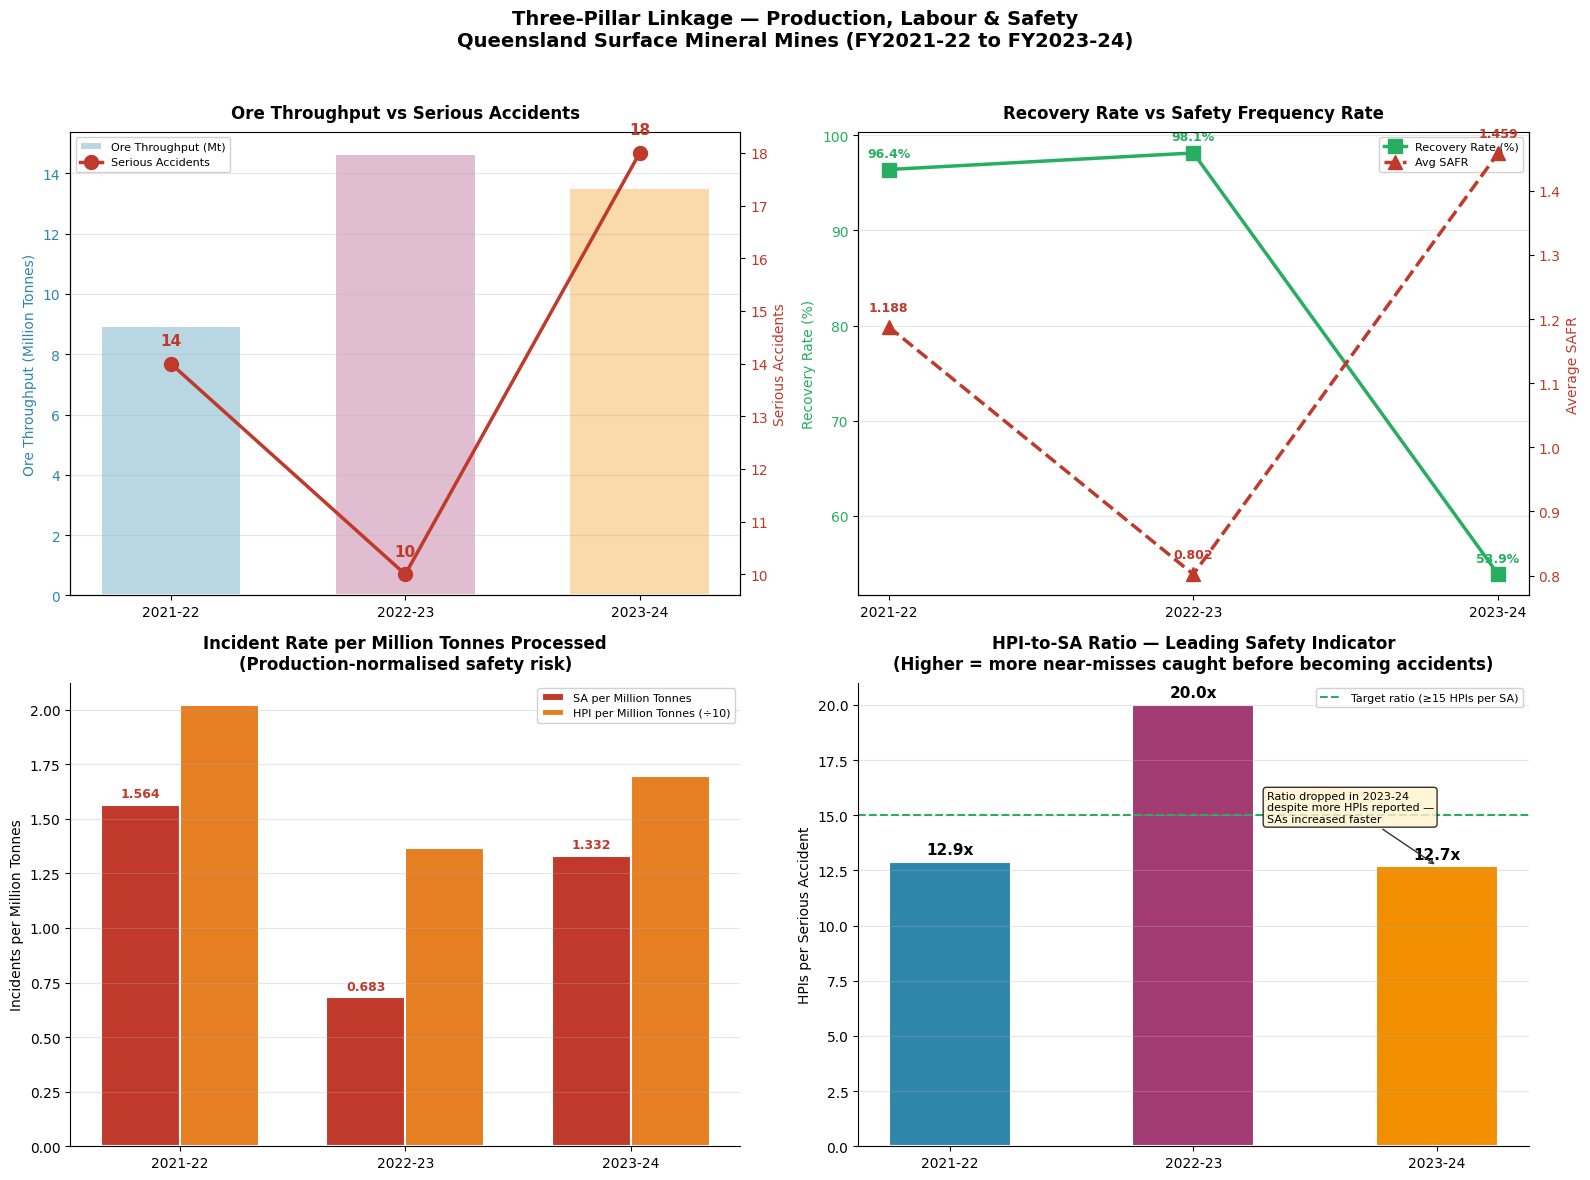

Chart saved to output/05_safety_production_linkage.png
Data saved to data/processed/safety/safety_monthly.csv
Data saved to data/processed/safety/safety_annual.csv
Data saved to data/processed/safety/safety_production_linked.csv


In [6]:
# CELL 6
# Visualise the relationship between production expansion and safety performance
# across the three overlapping financial years (2021-22 to 2023-24).
# This chart is the centrepiece of the three-pillar linkage narrative —
# showing that the expansion period drove simultaneous pressure on production
# efficiency (recovery rate) and safety performance (SAFR, incidents per Mt).
# All safety processed CSVs are saved at the end of this cell.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Three-Pillar Linkage — Production, Labour & Safety\n'
             'Queensland Surface Mineral Mines (FY2021-22 to FY2023-24)',
             fontsize=14, fontweight='bold', y=0.98)

# Filter to years with production data
df_linked = safety_production.dropna(subset=['ore_throughput_tonnes']).copy()
years = df_linked['financial_year'].tolist()
x = range(len(years))
colours = ['#2E86AB', '#A23B72', '#F18F01']

# --- Chart 1: Serious accidents vs ore throughput ---
ax1 = axes[0, 0]
ax1b = ax1.twinx()

bars = ax1.bar(x, df_linked['ore_throughput_tonnes'] / 1e6,
               color=[c + '55' for c in ['#2E86AB', '#A23B72', '#F18F01']],
               width=0.6, edgecolor='white', linewidth=1.5,
               label='Ore Throughput (Mt)')
line = ax1b.plot(x, df_linked['total_serious_accidents'],
                 color='#C0392B', linewidth=2.5, marker='o',
                 markersize=10, label='Serious Accidents', zorder=5)

ax1.set_title('Ore Throughput vs Serious Accidents',
              fontweight='bold', pad=10)
ax1.set_ylabel('Ore Throughput (Million Tonnes)', color='#2E86AB')
ax1b.set_ylabel('Serious Accidents', color='#C0392B')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1b.tick_params(axis='y', labelcolor='#C0392B')
ax1.tick_params(axis='y', labelcolor='#2E86AB')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=8, framealpha=0.9)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)

# Label accident counts
for i, val in enumerate(df_linked['total_serious_accidents']):
    ax1b.text(i, val + 0.3, str(int(val)),
              ha='center', va='bottom', fontweight='bold',
              color='#C0392B', fontsize=11)

# --- Chart 2: Recovery rate vs SAFR ---
ax2 = axes[0, 1]
ax2b = ax2.twinx()

ax2.plot(x, df_linked['recovery_rate_pct'],
         color='#27AE60', linewidth=2.5, marker='s',
         markersize=10, label='Recovery Rate (%)')
ax2b.plot(x, df_linked['avg_safr'],
          color='#C0392B', linewidth=2.5, marker='^',
          markersize=10, label='Avg SAFR', linestyle='--')

ax2.set_title('Recovery Rate vs Safety Frequency Rate',
              fontweight='bold', pad=10)
ax2.set_ylabel('Recovery Rate (%)', color='#27AE60')
ax2b.set_ylabel('Average SAFR', color='#C0392B')
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.tick_params(axis='y', labelcolor='#27AE60')
ax2b.tick_params(axis='y', labelcolor='#C0392B')

for i, (rr, safr) in enumerate(zip(df_linked['recovery_rate_pct'],
                                    df_linked['avg_safr'])):
    ax2.text(i, rr + 1, f'{rr:.1f}%',
             ha='center', va='bottom', fontsize=9,
             color='#27AE60', fontweight='bold')
    ax2b.text(i, safr + 0.02, f'{safr:.3f}',
              ha='center', va='bottom', fontsize=9,
              color='#C0392B', fontweight='bold')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right', fontsize=8, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)

# --- Chart 3: Incidents per million tonnes ---
ax3 = axes[1, 0]
width = 0.35
bars_sa = ax3.bar([i - width/2 for i in x],
                  df_linked['sa_per_million_tonnes'],
                  width=width, color='#C0392B',
                  edgecolor='white', linewidth=1.5,
                  label='SA per Million Tonnes')
bars_hpi = ax3.bar([i + width/2 for i in x],
                   df_linked['hpi_per_million_tonnes'] / 10,
                   width=width, color='#E67E22',
                   edgecolor='white', linewidth=1.5,
                   label='HPI per Million Tonnes (÷10)')

ax3.set_title('Incident Rate per Million Tonnes Processed\n'
              '(Production-normalised safety risk)',
              fontweight='bold', pad=10)
ax3.set_ylabel('Incidents per Million Tonnes')
ax3.set_xticks(x)
ax3.set_xticklabels(years)
ax3.legend(loc='upper right', fontsize=8, framealpha=0.9)

for bar, val in zip(bars_sa, df_linked['sa_per_million_tonnes']):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.3f}',
             ha='center', va='bottom', fontsize=9,
             fontweight='bold', color='#C0392B')
ax3.grid(axis='y', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- Chart 4: HPI to SA ratio ---
ax4 = axes[1, 1]
bars4 = ax4.bar(x, df_linked['hpi_to_sa_ratio'],
                color=colours, width=0.5,
                edgecolor='white', linewidth=1.5)

ax4.axhline(y=15, color='#27AE60', linestyle='--',
            linewidth=1.5, label='Target ratio (≥15 HPIs per SA)')
ax4.set_title('HPI-to-SA Ratio — Leading Safety Indicator\n'
              '(Higher = more near-misses caught before becoming accidents)',
              fontweight='bold', pad=10)
ax4.set_ylabel('HPIs per Serious Accident')
ax4.set_xticks(x)
ax4.set_xticklabels(years)
ax4.legend(loc='upper right', fontsize=8, framealpha=0.9)

for bar, val in zip(bars4, df_linked['hpi_to_sa_ratio']):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val:.1f}x',
             ha='center', va='bottom',
             fontweight='bold', fontsize=11)

ax4.annotate('Ratio dropped in 2023-24\ndespite more HPIs reported —\nSAs increased faster',
             xy=(2, df_linked['hpi_to_sa_ratio'].iloc[2]),
             xytext=(1.3, df_linked['hpi_to_sa_ratio'].iloc[2] + 2),
             arrowprops=dict(arrowstyle='->', color='#333333'),
             fontsize=8,
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='#FFF3CD', alpha=0.8))
ax4.grid(axis='y', alpha=0.3)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])

output_dir = os.path.join('..', 'output')
plt.savefig(os.path.join(output_dir, '05_safety_production_linkage.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to output/05_safety_production_linkage.png")

# Save all safety CSVs
processed_dir = os.path.join('..', 'data', 'processed', 'safety')
os.makedirs(processed_dir, exist_ok=True)

df_safety.to_csv(
    os.path.join(processed_dir, 'safety_monthly.csv'), index=False)
df_safety_annual.to_csv(
    os.path.join(processed_dir, 'safety_annual.csv'), index=False)
safety_production.to_csv(
    os.path.join(processed_dir, 'safety_production_linked.csv'), index=False)

print("Data saved to data/processed/safety/safety_monthly.csv")
print("Data saved to data/processed/safety/safety_annual.csv")
print("Data saved to data/processed/safety/safety_production_linked.csv")